In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import NearMiss
from imblearn.under_sampling import RandomUnderSampler

In [2]:
testset  = pd.read_csv('/content/drive/MyDrive/data-b/testset.csv')
trainset = pd.read_csv('/content/drive/MyDrive/data-b/trainset.csv')

data disaugmenter

In [ ]:
X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]
stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)


      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      decision_tree = DecisionTreeClassifier(random_state=42,max_depth=10,criterion='entropy')
      decision_tree.fit(X_train, y_train)
      models.append(decision_tree)

      # Prédiction sur l'ensemble de test
      y_pred = decision_tree.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()

mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()


rf

Accuracy: 0.91
Precision: 0.91
Recall: 0.91
F1 Score: 0.91
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       484
           1       0.91      0.91      0.91       484

    accuracy                           0.91       968
   macro avg       0.91      0.91      0.91       968
weighted avg       0.91      0.91      0.91       968



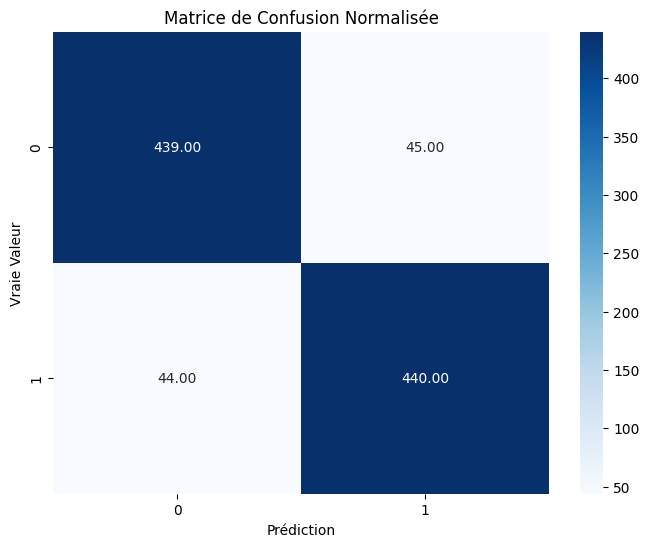

Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.90
Precision: 0.92
Recall: 0.88
F1 Score: 0.90
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       622
           1       0.92      0.88      0.90       622

    accuracy                           0.90      1244
   macro avg       0.90      0.90      0.90      1244
weighted avg       0.90      0.90      0.90      1244



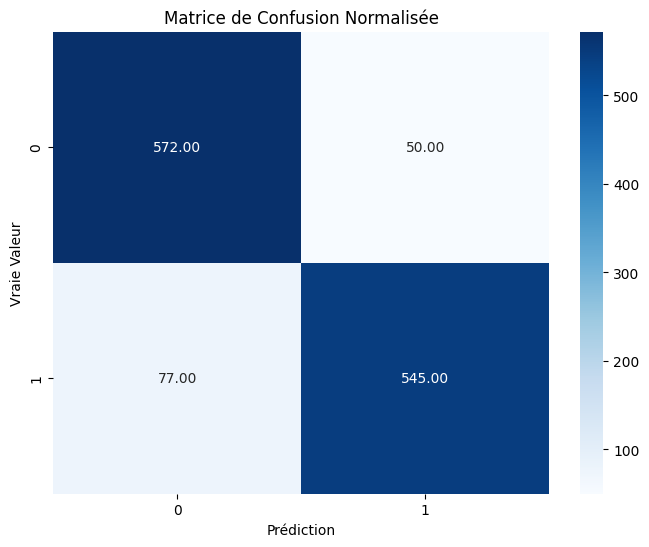

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      random_forest = RandomForestClassifier(n_estimators=200,max_depth=35)
      random_forest.fit(X_train, y_train)
      models.append(random_forest)
      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()



In [ ]:
import joblib

models = random_forest
joblib.dump(model, f'/content/rfAugModel.pkl')


['/content/rfAugModel.pkl']

xgboost

Accuracy: 0.90
Precision: 0.89
Recall: 0.91
F1 Score: 0.90
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       484
           1       0.89      0.91      0.90       484

    accuracy                           0.90       968
   macro avg       0.90      0.90      0.90       968
weighted avg       0.90      0.90      0.90       968



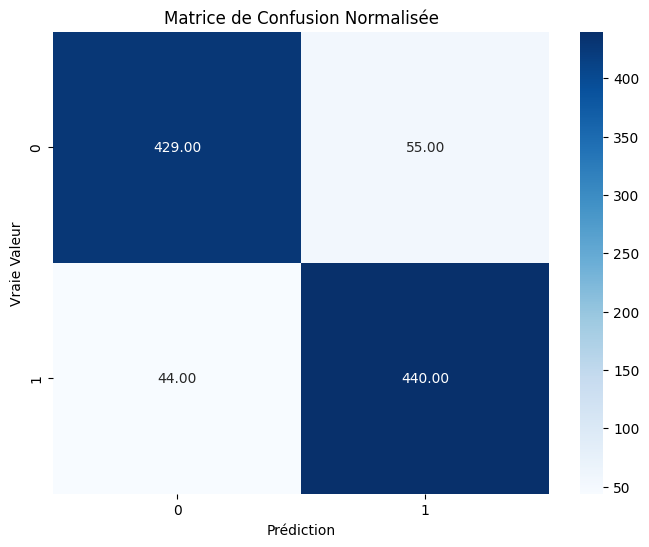

Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.90
Precision: 0.90
Recall: 0.90
F1 Score: 0.90
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       622
           1       0.90      0.90      0.90       622

    accuracy                           0.90      1244
   macro avg       0.90      0.90      0.90      1244
weighted avg       0.90      0.90      0.90      1244



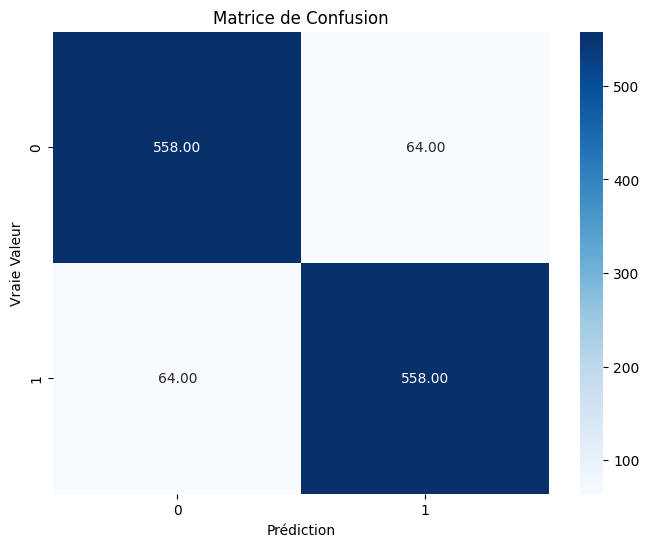

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      random_forest = xgb.XGBClassifier(# Pour une classification binaire, utiliser 'binary:logistic'
    max_depth=35,                  # Profondeur maximale de l'arbre
    learning_rate=0.1,            # Taux d'apprentissage (learning rate)
    n_estimators=100,             # Nombre d'estimateurs (arbres)
    random_state=42               # Seed pour la reproductibilité des résultats
)
      random_forest.fit(X_train, y_train)
      models.append(random_forest)
      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion')
plt.show()

svm


Accuracy: 0.82
Precision: 0.80
Recall: 0.86
F1 Score: 0.83
              precision    recall  f1-score   support

           0       0.85      0.78      0.82       478
           1       0.80      0.86      0.83       478

    accuracy                           0.82       956
   macro avg       0.82      0.82      0.82       956
weighted avg       0.82      0.82      0.82       956



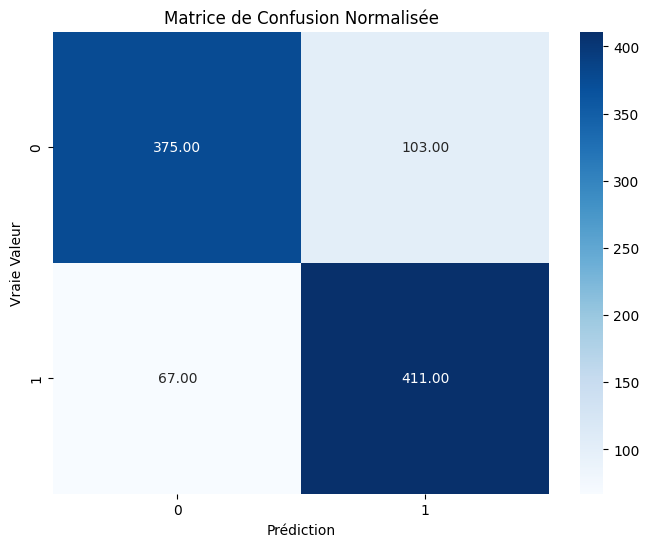

Accuracy: 0.83
Precision: 0.82
Recall: 0.85
F1 Score: 0.83
              precision    recall  f1-score   support

           0       0.84      0.81      0.83       478
           1       0.82      0.85      0.83       478

    accuracy                           0.83       956
   macro avg       0.83      0.83      0.83       956
weighted avg       0.83      0.83      0.83       956



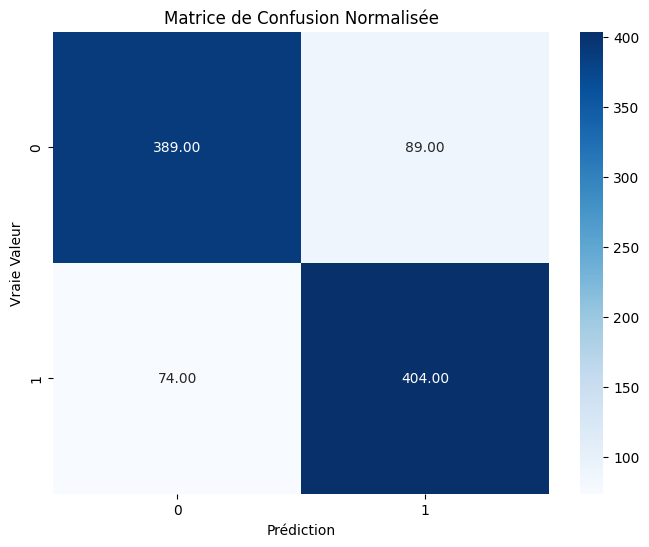

Accuracy: 0.82
Precision: 0.81
Recall: 0.84
F1 Score: 0.82
              precision    recall  f1-score   support

           0       0.83      0.80      0.82       478
           1       0.81      0.84      0.82       478

    accuracy                           0.82       956
   macro avg       0.82      0.82      0.82       956
weighted avg       0.82      0.82      0.82       956



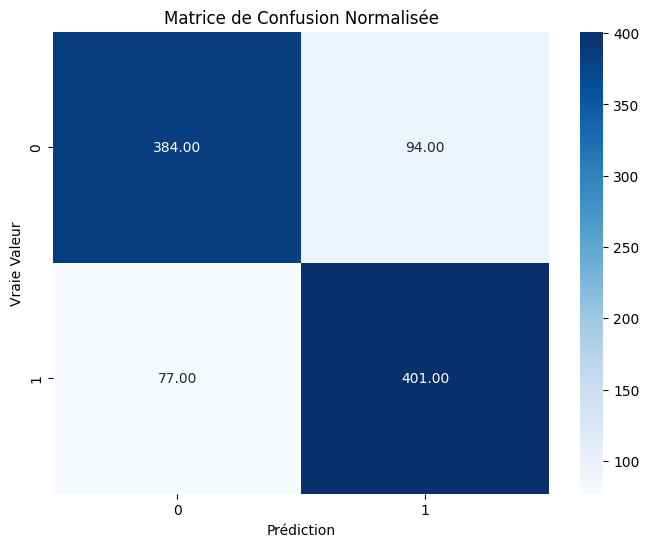

Accuracy: 0.80
Precision: 0.78
Recall: 0.83
F1 Score: 0.80
              precision    recall  f1-score   support

           0       0.82      0.77      0.79       478
           1       0.78      0.83      0.80       478

    accuracy                           0.80       956
   macro avg       0.80      0.80      0.80       956
weighted avg       0.80      0.80      0.80       956



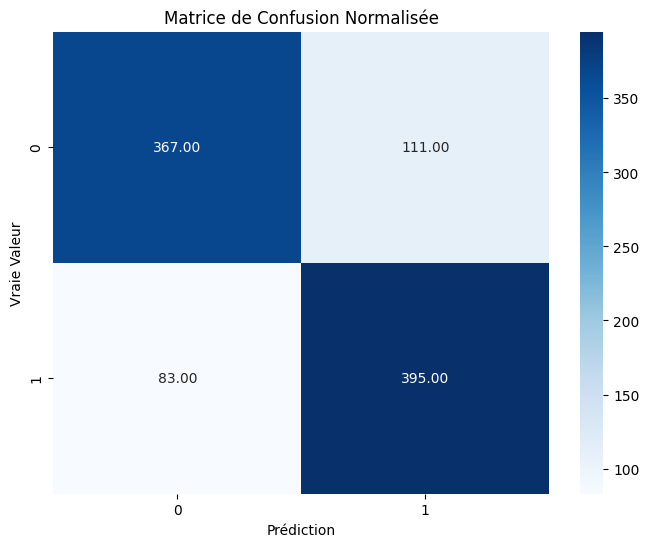

Accuracy: 0.82
Precision: 0.80
Recall: 0.86
F1 Score: 0.83
              precision    recall  f1-score   support

           0       0.85      0.78      0.81       478
           1       0.80      0.86      0.83       478

    accuracy                           0.82       956
   macro avg       0.82      0.82      0.82       956
weighted avg       0.82      0.82      0.82       956



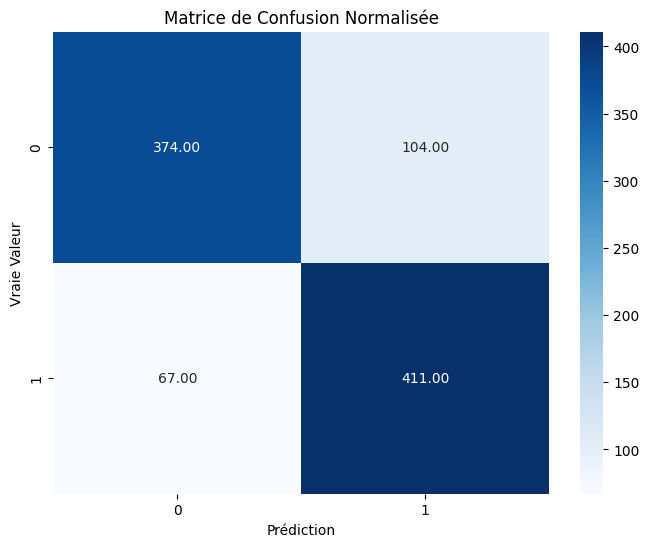

Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.79
Precision: 0.78
Recall: 0.81
F1 Score: 0.80
              precision    recall  f1-score   support

           0       0.81      0.77      0.79       653
           1       0.78      0.81      0.80       653

    accuracy                           0.79      1306
   macro avg       0.79      0.79      0.79      1306
weighted avg       0.79      0.79      0.79      1306



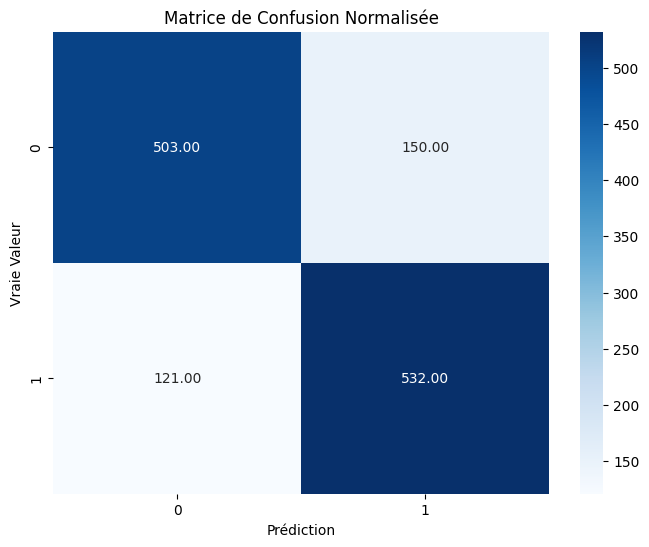

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.svm import SVC

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_train,y_train = undersampler.fit_resample(X_train,y_train)

      undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

      X_val,y_val = undersampler.fit_resample(X_val,y_val)
      svm_model = SVC(kernel='rbf',C=1000,random_state=42)
      svm_model.fit(X_train, y_train)
      models.append(svm_model)
      y_pred = svm_model.predict(X_val)

      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()
mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()

ann

Accuracy: 0.79
Precision: 0.03
Recall: 0.85
F1 Score: 0.06
              precision    recall  f1-score   support

           0       1.00      0.79      0.88     58141
           1       0.03      0.85      0.06       478

    accuracy                           0.79     58619
   macro avg       0.51      0.82      0.47     58619
weighted avg       0.99      0.79      0.87     58619



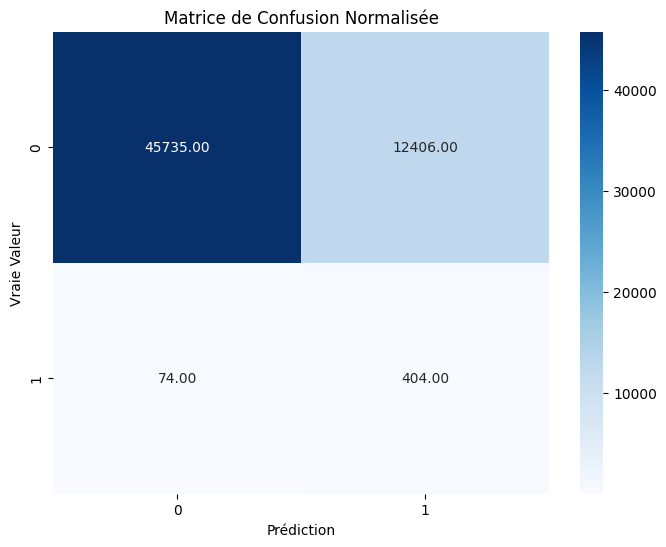

Accuracy: 0.76
Precision: 0.03
Recall: 0.84
F1 Score: 0.05
              precision    recall  f1-score   support

           0       1.00      0.75      0.86     58141
           1       0.03      0.84      0.05       478

    accuracy                           0.76     58619
   macro avg       0.51      0.80      0.46     58619
weighted avg       0.99      0.76      0.85     58619



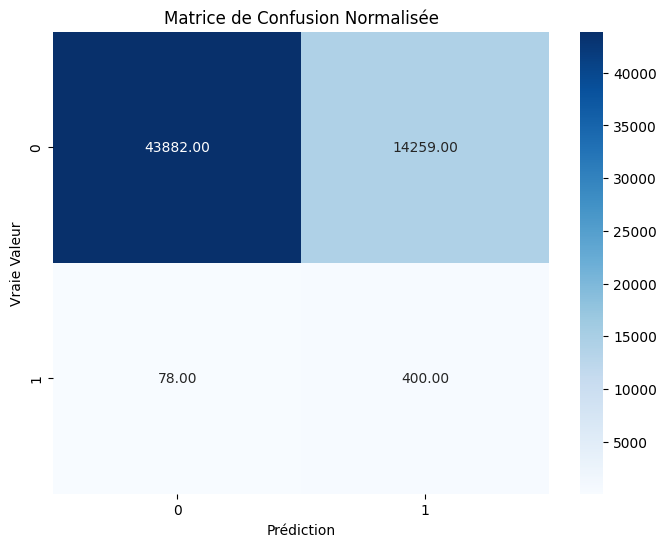

Accuracy: 0.80
Precision: 0.03
Recall: 0.81
F1 Score: 0.06
              precision    recall  f1-score   support

           0       1.00      0.80      0.89     58141
           1       0.03      0.81      0.06       478

    accuracy                           0.80     58619
   macro avg       0.52      0.80      0.47     58619
weighted avg       0.99      0.80      0.88     58619



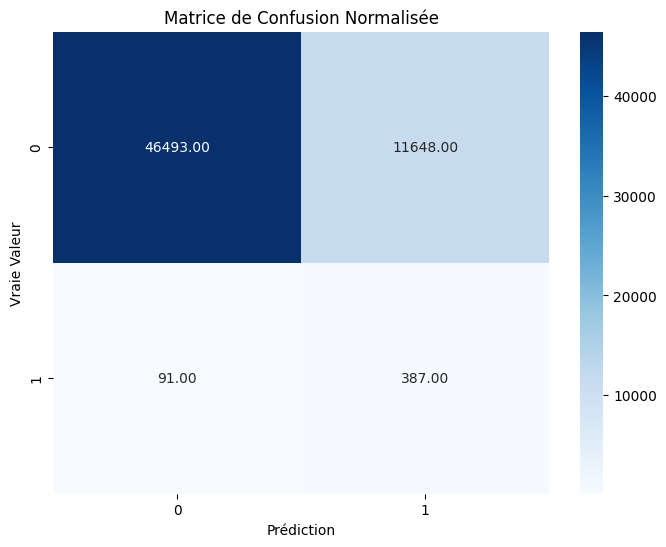

Accuracy: 0.79
Precision: 0.03
Recall: 0.81
F1 Score: 0.06
              precision    recall  f1-score   support

           0       1.00      0.79      0.88     58141
           1       0.03      0.81      0.06       478

    accuracy                           0.79     58619
   macro avg       0.51      0.80      0.47     58619
weighted avg       0.99      0.79      0.88     58619



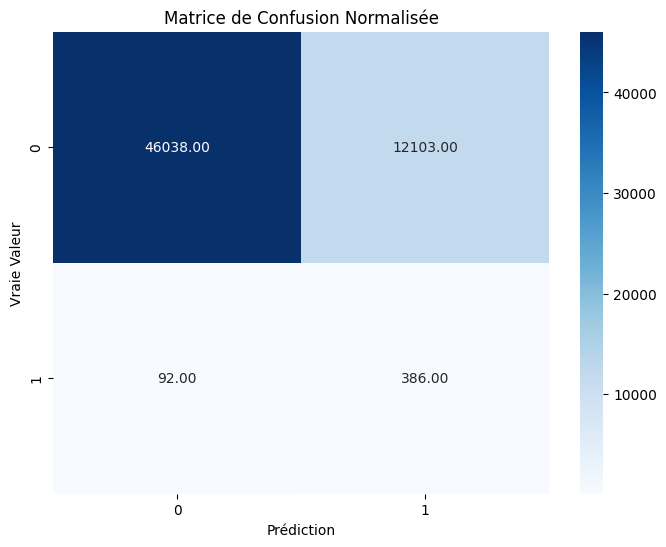

Accuracy: 0.81
Precision: 0.04
Recall: 0.86
F1 Score: 0.07
              precision    recall  f1-score   support

           0       1.00      0.81      0.89     58141
           1       0.04      0.86      0.07       478

    accuracy                           0.81     58619
   macro avg       0.52      0.83      0.48     58619
weighted avg       0.99      0.81      0.88     58619



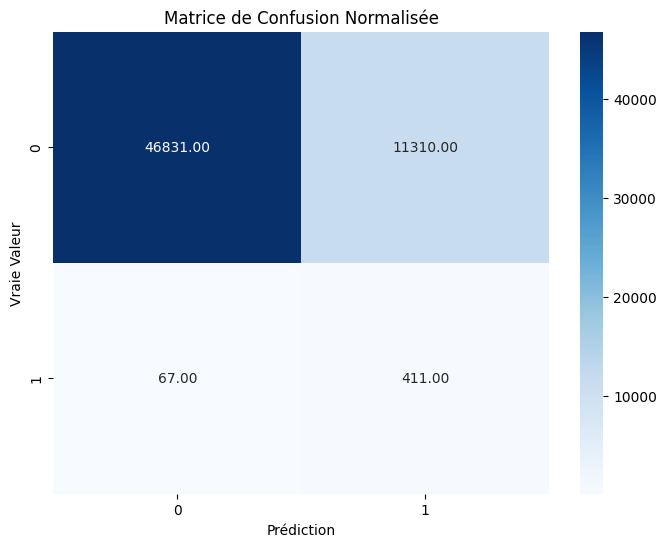

Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.75
Precision: 0.71
Recall: 0.82
F1 Score: 0.76
              precision    recall  f1-score   support

           0       0.79      0.67      0.72       653
           1       0.71      0.82      0.76       653

    accuracy                           0.75      1306
   macro avg       0.75      0.75      0.74      1306
weighted avg       0.75      0.75      0.74      1306



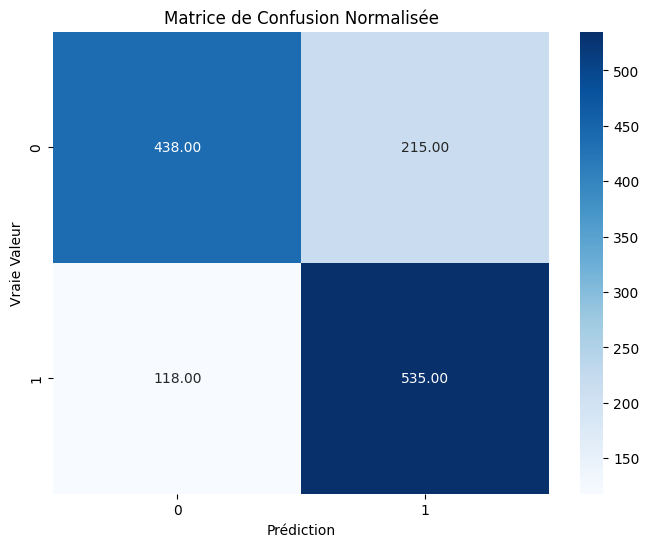

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier  # Importez MLPClassifier

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models = []
recalls = []

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X, y):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    # Créer un objet StandardScaler
    scaler = StandardScaler()

    # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
    X_train = scaler.fit_transform(X_train)
    # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
    X_val = scaler.transform(X_val)

    undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
    X_train, y_train = undersampler.fit_resample(X_train, y_train)

    # Créer et entraîner le modèle MLPClassifier
    mlp_model = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=1000, alpha=0.0001,
                              solver='sgd', random_state=42, tol=1e-4,early_stopping=True)
    mlp_model.fit(X_train, y_train)
    models.append(mlp_model)
    y_pred = mlp_model.predict(X_val)

    # Évaluation du modèle
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    recalls.append(recall)
    f1 = f1_score(y_val, y_pred)

    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")

    # Affichage du rapport de classification
    print(classification_report(y_val, y_pred))

    # Matrice de confusion
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.title('Matrice de Confusion Normalisée')
    plt.show()

mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()


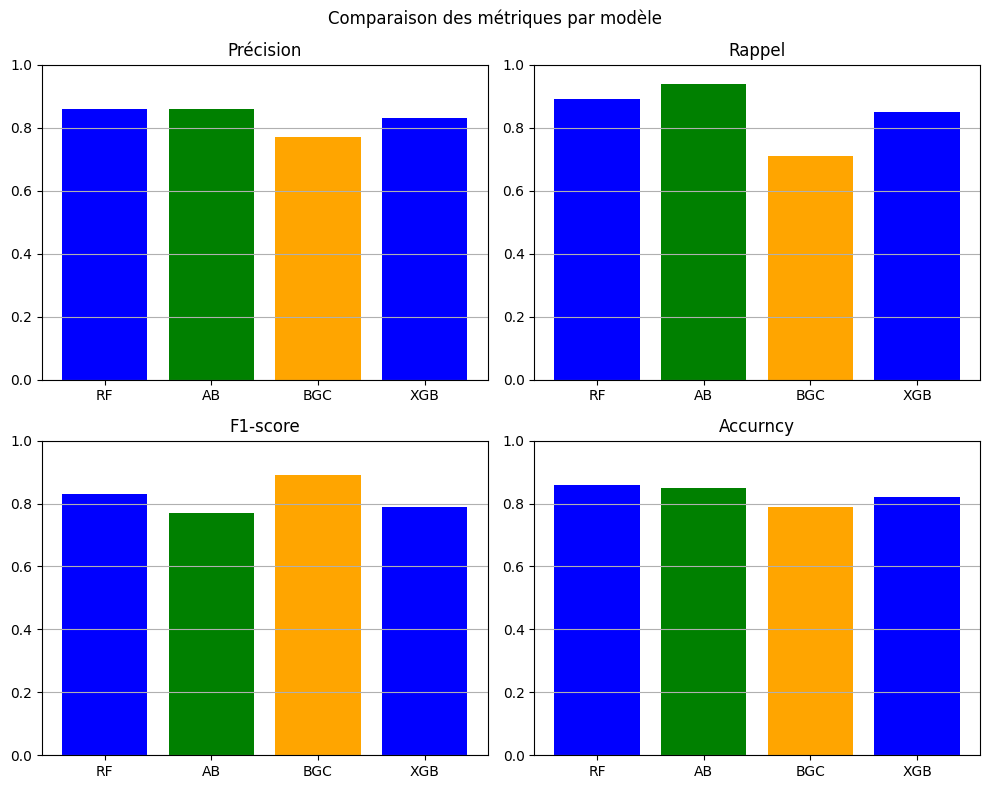

'scores = np.array([[0.73,0.77,0.66,0.71],\n                    [0.78,0.75,0.83,0.79],\n                    [0.77,0.71,0.89,0,79],\n                    [0.79,0.74,0.89,0.81],\n                    [0.79,0.75,0.89,0.81]\n                  ])\n                  [0.86,0.89,0.83,0.86],\n[0.86,0.94,0.77,0.85],\n[0.77,0.71,0.89,0.79]\n'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Données factices pour les métriques de trois modèles
models = ['RF','AB','BGC','XGB']
metrics = ['Précision', 'Rappel', 'F1-score', 'Accurncy']
scores = np.array([[0.86,0.89,0.83,0.86],
                   [0.86,0.94,0.77,0.85],
                   [0.77,0.71,0.89,0.79],
                   [0.83,0.85,0.79,0.82]
                   ])

# Création des sous-graphiques pour chaque métrique
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Comparaison des métriques par modèle')

# Parcours des métriques et affichage des histogrammes
for i in range(len(metrics)):
    row = i // 2  # Ligne du sous-graphique
    col = i % 2   # Colonne du sous-graphique
    axs[row, col].bar(models, scores[:, i], color=['blue', 'green', 'orange'])
    axs[row, col].set_title(metrics[i])
    axs[row, col].set_ylim(0, 1)  # Échelle de 0 à 1 pour les métriques
    axs[row, col].grid(axis='y')

# Réglage des marges et affichage global
plt.tight_layout()
plt.show()
'''scores = np.array([[0.73,0.77,0.66,0.71],
                    [0.78,0.75,0.83,0.79],
                    [0.77,0.71,0.89,0,79],
                    [0.79,0.74,0.89,0.81],
                    [0.79,0.75,0.89,0.81]
                  ])
                  [0.86,0.89,0.83,0.86],
[0.86,0.94,0.77,0.85],
[0.77,0.71,0.89,0.79]
'''

data augmente suite

ann

Epoch 1/100
14536/14536 [==============================] - 56s 4ms/step - loss: 0.1855 - accuracy: 0.9269
Epoch 2/100
14536/14536 [==============================] - 39s 3ms/step - loss: 0.1119 - accuracy: 0.9624
Epoch 3/100
14536/14536 [==============================] - 38s 3ms/step - loss: 0.0911 - accuracy: 0.9707
Epoch 4/100
14536/14536 [==============================] - 41s 3ms/step - loss: 0.0801 - accuracy: 0.9748
Epoch 5/100
14536/14536 [==============================] - 37s 3ms/step - loss: 0.0716 - accuracy: 0.9779
Epoch 6/100
14536/14536 [==============================] - 42s 3ms/step - loss: 0.0667 - accuracy: 0.9799
Epoch 7/100
14536/14536 [==============================] - 39s 3ms/step - loss: 0.0618 - accuracy: 0.9814
Epoch 8/100
14536/14536 [==============================] - 38s 3ms/step - loss: 0.0577 - accuracy: 0.9828
Epoch 9/100
14536/14536 [==============================] - 38s 3ms/step - loss: 0.0546 - accuracy: 0.9840
Epoch 10/100
14536/14536 [====================

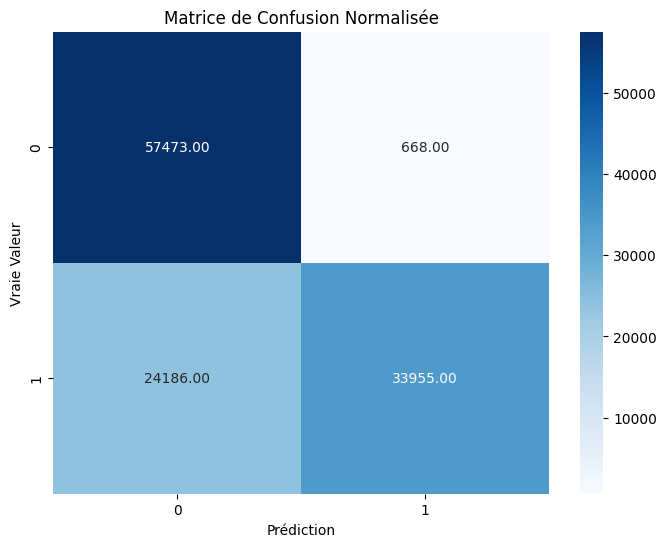

41/41 [==============================] - 0s 2ms/step
Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.61
Precision: 0.97
Recall: 0.22
F1 Score: 0.36
              precision    recall  f1-score   support

           0       0.56      0.99      0.72       653
           1       0.97      0.22      0.36       653

    accuracy                           0.61      1306
   macro avg       0.77      0.61      0.54      1306
weighted avg       0.77      0.61      0.54      1306



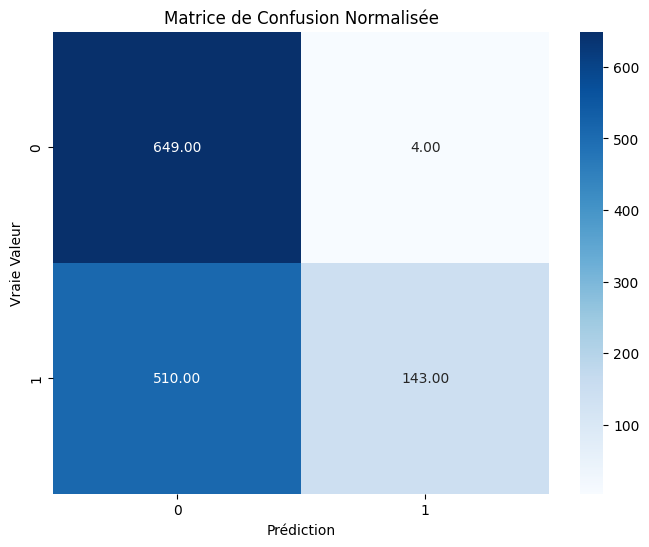

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      smote = SMOTE(sampling_strategy='auto')
      X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
      X_train=X_resampled
      y_train=y_resampled

      smote = SMOTE(sampling_strategy='auto')
      X_resampled, y_resampled = smote.fit_resample(X_val, y_val)
      X_val=X_resampled
      y_val=y_resampled


      # Créer le modèle séquentiel
      model = Sequential([
          Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
          Dense(64, activation='relu'),
          Dense(32, activation='relu'),
          Dense(16, activation='relu'),
          Dense(8, activation='relu'),
          Dense(1, activation='sigmoid')
      ])

      # Compiler le modèle
      model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])


# Entraîner le modèle
      history = model.fit(X_train, y_train, epochs=100)
      y_pred = (model.predict(X_val) > 0.5).astype("int32")


      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()

X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()


mlp

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier  # Importez MLPClassifier

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models = []
recalls = []

stratified_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X, y):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    # Créer un objet StandardScaler
    scaler = StandardScaler()

    # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
    X_train = scaler.fit_transform(X_train)
    # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
    X_val = scaler.transform(X_val)

    undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
    X_train, y_train = undersampler.fit_resample(X_train, y_train)

    # Créer et entraîner le modèle MLPClassifier
    mlp_model = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=1000, alpha=0.0001,
                              solver='sgd', random_state=42, tol=1e-4,early_stopping=True)
    mlp_model.fit(X_train, y_train)
    models.append(mlp_model)
    y_pred = mlp_model.predict(X_val)

    # Évaluation du modèle
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    recalls.append(recall)
    f1 = f1_score(y_val, y_pred)

    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")

    # Affichage du rapport de classification
    print(classification_report(y_val, y_pred))

    # Matrice de confusion
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.title('Matrice de Confusion Normalisée')
    plt.show()

mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()


ad

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier,RandomForestClassifier

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models=[]
recalls=[]

stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X,y):
      X_train, X_val = X.iloc[train_index], X.iloc[val_index]
      y_train, y_val = y.iloc[train_index], y.iloc[val_index]

# Créer un objet StandardScaler
      scaler = StandardScaler()

      # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
      X_train = scaler.fit_transform(X_train)
      # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
      X_val = scaler.transform(X_val)


      smote = SMOTE(sampling_strategy='auto')
      X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
      X_train=X_resampled
      y_train=y_resampled

      smote = SMOTE(sampling_strategy='auto')
      X_resampled, y_resampled = smote.fit_resample(X_val, y_val)
      X_val=X_resampled
      y_val=y_resampled

      # Création et entraînement du modèle SVM avec poids de classe personnalisés
      #class_weight={0:1,1:99}
      random_forest = BaggingClassifier(LogisticRegression(C=0.1, solver='newton-cg', max_iter=1000,tol=1e-4), n_estimators=500,random_state=42)
      random_forest.fit(X_train, y_train)
      models.append(random_forest)

      # Prédiction sur l'ensemble de test
      y_pred = random_forest.predict(X_val)


      # Évaluation du modèle
      accuracy = accuracy_score(y_val, y_pred)
      precision = precision_score(y_val, y_pred)
      recall = recall_score(y_val, y_pred)
      recalls.append(recall)
      f1 = f1_score(y_val, y_pred)


      print(f"Accuracy: {accuracy:.2f}")
      print(f"Precision: {precision:.2f}")
      print(f"Recall: {recall:.2f}")
      print(f"F1 Score: {f1:.2f}")

      # Affichage du rapport de classification
      print(classification_report(y_val, y_pred))

      # Matrice de confusion
      cm = confusion_matrix(y_val, y_pred)
      #cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
      plt.figure(figsize=(8, 6))
      sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
      plt.xlabel('Prédiction')
      plt.ylabel('Vraie Valeur')
      plt.title('Matrice de Confusion Normalisée')
      plt.show()


# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = models[0]

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()

/usr/local/lib/python3.10/dist-packages/scipy/optimize/_linesearch.py:314: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/optimize.py:203: UserWarning: Line Search failed
  warnings.warn("Line Search failed")
/usr/local/lib/python3.10/dist-packages/scipy/optimize/_linesearch.py:314: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/optimize.py:203: UserWarning: Line Search failed
  warnings.warn("Line Search failed")
/usr/local/lib/python3.10/dist-packages/scipy/optimize/_linesearch.py:314: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/optimize.py:203: UserWarning: Line Se

In [ ]:
import sklearn
print(sklearn.__version__)

1.2.2


lmp m3awda knt ghlta disaugm

Accuracy: 0.85
Precision: 0.84
Recall: 0.85
F1 Score: 0.85
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       484
           1       0.84      0.85      0.85       484

    accuracy                           0.85       968
   macro avg       0.85      0.85      0.85       968
weighted avg       0.85      0.85      0.85       968



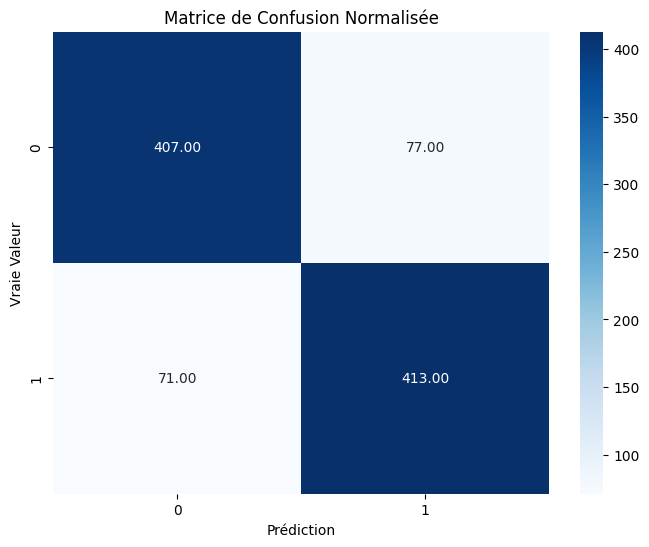

Modèle sélectionné avec un rappel proche de la moyenne des rappels.
Accuracy: 0.81
Precision: 0.75
Recall: 0.91
F1 Score: 0.83
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       622
           1       0.75      0.91      0.83       622

    accuracy                           0.81      1244
   macro avg       0.82      0.81      0.80      1244
weighted avg       0.82      0.81      0.80      1244



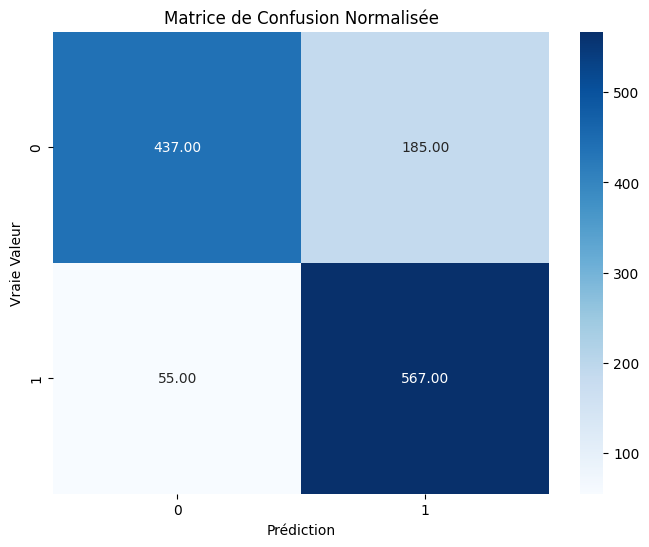

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier  # Importez MLPClassifier
from imblearn.over_sampling import SMOTE

X = trainset.drop(columns=['fire'])
y = trainset['fire']
models = []
recalls = []

stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Diviser les données en ensembles d'entraînement et de validation
for train_index, val_index in stratified_split.split(X, y):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    # Créer un objet StandardScaler
    scaler = StandardScaler()

    # Ajuster (fit) le standardiseur sur l'ensemble d'entraînement et standardiser les données
    X_train = scaler.fit_transform(X_train)
    # Utiliser les mêmes paramètres de standardisation pour standardiser l'ensemble de test
    X_val = scaler.transform(X_val)

    undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

    X_train,y_train = undersampler.fit_resample(X_train,y_train)

    undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

    X_val,y_val = undersampler.fit_resample(X_val,y_val)

    # Créer et entraîner le modèle MLPClassifier
    mlp_model = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=1000, alpha=0.0001,
                              solver='lbfgs', random_state=42, early_stopping=True)


    mlp_model.fit(X_train, y_train)
    models.append(mlp_model)
    y_pred = mlp_model.predict(X_val)

    # Évaluation du modèle
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    recalls.append(recall)
    f1 = f1_score(y_val, y_pred)

    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")

    # Affichage du rapport de classification
    print(classification_report(y_val, y_pred))

    # Matrice de confusion
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.title('Matrice de Confusion Normalisée')
    plt.show()

mean_recall = np.mean(recalls)

# Trouver le modèle le plus proche de la moyenne des rappels
closest_model = None
closest_recall_diff = float('inf')  # Initialisation avec une valeur infinie
for model, recall in zip(models, recalls):
    recall_diff = abs(recall - mean_recall)
    if recall_diff < closest_recall_diff:
        closest_model = model
        closest_recall_diff = recall_diff

# Utiliser le modèle sélectionné pour faire des prédictions sur un ensemble de test
X_test = testset.drop(columns=['fire'])
y_test = testset['fire']
X_test = scaler.transform(X_test)
y_pred = closest_model.predict(X_test)

# Évaluation du modèle sélectionné
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Modèle sélectionné avec un rappel proche de la moyenne des rappels.")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Affichage du rapport de classification
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.title('Matrice de Confusion Normalisée')
plt.show()

In [ ]:
testset  = pd.read_csv('/content/drive/MyDrive/data-b/testset.csv')
trainset = pd.read_csv('/content/drive/MyDrive/data-b/trainset.csv')